# Stochastic Process Diagnostics

This notebook visualizes each process used by the fleet replacement environment in isolation.


In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from fleet_replacement.config import load_env_config
from fleet_replacement.envs.models import (
    BET_price_step,
    BET_productivity_logistic,
    diesel_price_step,
    DT_price_step,
    electricity_price_step,
)

In [2]:
config_path = Path.cwd() / "configs" / "env.yaml"
if not config_path.exists():
    config_path = Path.cwd().parent / "configs" / "env.yaml"
config = load_env_config(config_path)

start_year = config.simulation_period.base_year
n_years = config.simulation_period.final_year - config.simulation_period.base_year
n_paths = 300
seed = 7
rng = np.random.default_rng(seed)

In [3]:
def simulate_paths(step_fn, initial_value, n_years, n_paths, rng):
    paths = np.zeros((n_paths, n_years + 1), dtype=float)
    paths[:, 0] = initial_value
    for p in range(n_paths):
        value = float(initial_value)
        for t in range(1, n_years + 1):
            value = step_fn(value, rng)
            paths[p, t] = value
    return paths


def plot_path_ensemble(paths, title, ylabel):
    t = np.arange(paths.shape[1])
    q05 = np.quantile(paths, 0.05, axis=0)
    q50 = np.quantile(paths, 0.50, axis=0)
    q95 = np.quantile(paths, 0.95, axis=0)

    plt.figure(figsize=(9, 5))
    for i in range(min(30, paths.shape[0])):
        plt.plot(t, paths[i], alpha=0.12, color="tab:blue")
    plt.fill_between(
        t, q05, q95, color="tab:orange", alpha=0.25, label="5-95% interval"
    )
    plt.plot(t, q50, color="tab:red", lw=2, label="Median")
    plt.title(title)
    plt.xlabel("Years from base year")
    plt.ylabel(ylabel)
    plt.grid(alpha=0.25)
    plt.legend()
    plt.show()

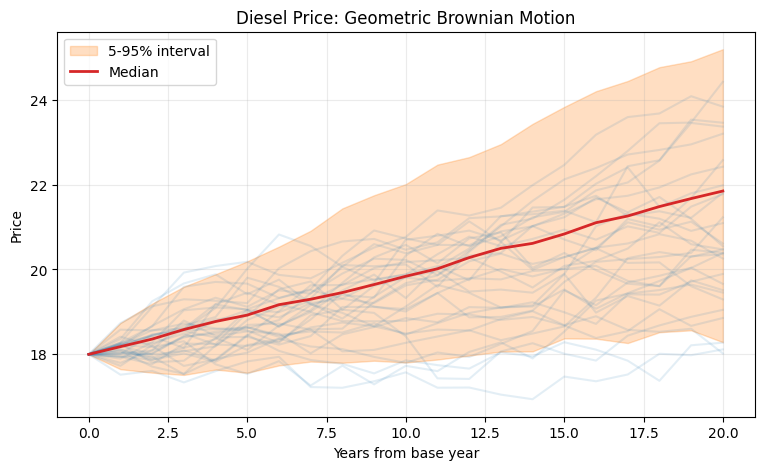

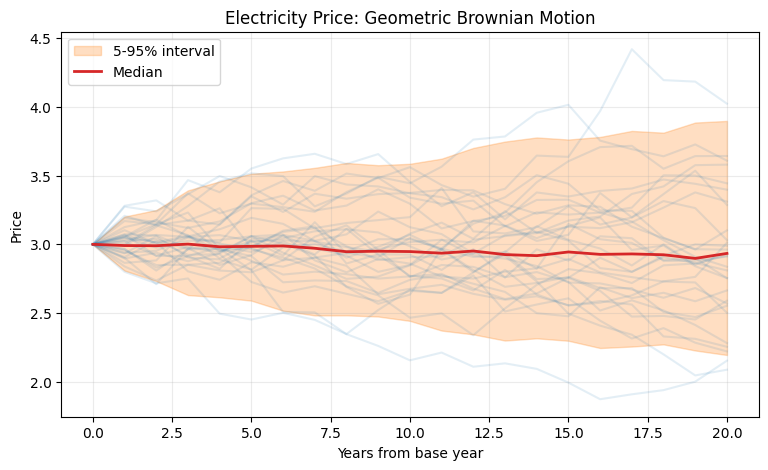

In [4]:
diesel_paths = simulate_paths(
    step_fn=lambda value, local_rng: diesel_price_step(
        value, config.diesel_price, local_rng
    ),
    initial_value=config.diesel_price.initial_price,
    n_years=n_years,
    n_paths=n_paths,
    rng=rng,
)

electricity_paths = simulate_paths(
    step_fn=lambda value, local_rng: electricity_price_step(
        value, config.electricity_price, local_rng
    ),
    initial_value=config.electricity_price.initial_price,
    n_years=n_years,
    n_paths=n_paths,
    rng=rng,
)

plot_path_ensemble(diesel_paths, "Diesel Price: Geometric Brownian Motion", "Price")
plot_path_ensemble(
    electricity_paths, "Electricity Price: Geometric Brownian Motion", "Price"
)

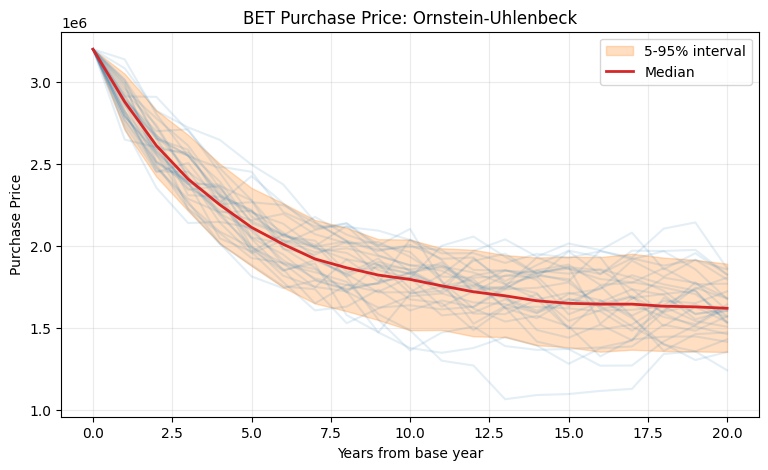

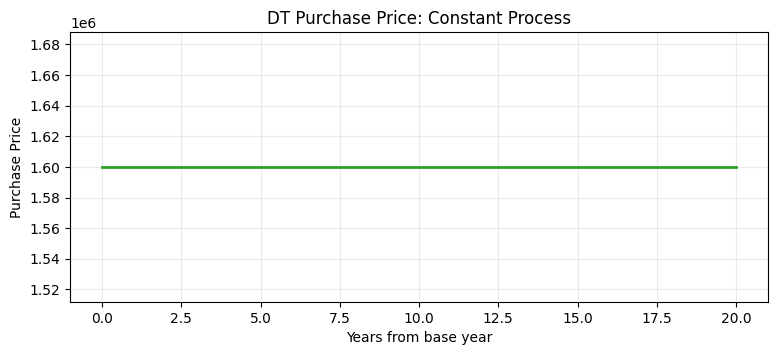

In [5]:
bet_paths = simulate_paths(
    step_fn=lambda value, local_rng: BET_price_step(value, config.BET_price, local_rng),
    initial_value=config.BET_price.initial_price,
    n_years=n_years,
    n_paths=n_paths,
    rng=rng,
)

dt_constant = np.array(
    [DT_price_step(config.DT_price.initial_price) for _ in range(n_years + 1)],
    dtype=float,
)

plot_path_ensemble(
    bet_paths, "BET Purchase Price: Ornstein-Uhlenbeck", "Purchase Price"
)

plt.figure(figsize=(9, 3.5))
plt.plot(np.arange(n_years + 1), dt_constant, color="tab:green", lw=2)
plt.title("DT Purchase Price: Constant Process")
plt.xlabel("Years from base year")
plt.ylabel("Purchase Price")
plt.grid(alpha=0.25)
plt.show()

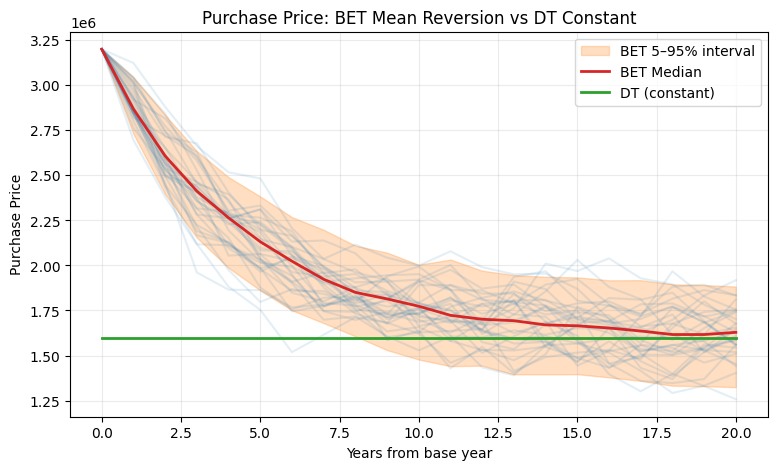

In [6]:
bet_paths = simulate_paths(
    step_fn=lambda value, local_rng: BET_price_step(value, config.BET_price, local_rng),
    initial_value=config.BET_price.initial_price,
    n_years=n_years,
    n_paths=n_paths,
    rng=rng,
)

dt_constant = np.array(
    [DT_price_step(config.DT_price.initial_price) for _ in range(n_years + 1)],
    dtype=float,
)

t = np.arange(n_years + 1)
q05 = np.quantile(bet_paths, 0.05, axis=0)
q50 = np.quantile(bet_paths, 0.50, axis=0)
q95 = np.quantile(bet_paths, 0.95, axis=0)

plt.figure(figsize=(9, 5))
for i in range(min(30, bet_paths.shape[0])):
    plt.plot(t, bet_paths[i], alpha=0.12, color="tab:blue")

plt.fill_between(
    t, q05, q95, color="tab:orange", alpha=0.25, label="BET 5–95% interval"
)
plt.plot(t, q50, color="tab:red", lw=2, label="BET Median")
plt.plot(t, dt_constant, color="tab:green", lw=2, label="DT (constant)")
plt.title("Purchase Price: BET Mean Reversion vs DT Constant")
plt.xlabel("Years from base year")
plt.ylabel("Purchase Price")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

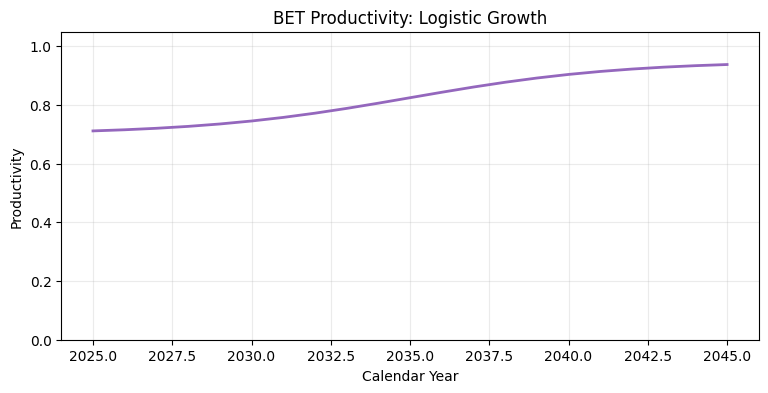

In [9]:
years = np.arange(start_year, start_year + n_years + 1)
productivity = np.array(
    [BET_productivity_logistic(int(y), config.BET_productivity) for y in years],
    dtype=float,
)

plt.figure(figsize=(9, 4))
plt.plot(years, productivity, lw=2, color="tab:purple")
plt.title("BET Productivity: Logistic Growth")
plt.xlabel("Calendar Year")
plt.ylabel("Productivity")
plt.ylim(0.0, 1.05)
plt.grid(alpha=0.25)
plt.show()